In [1]:
# --------------------------------------------------
# Project Root
# --------------------------------------------------

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

d:\IITG\Projects\audio_factor_disentanglement_v2


In [2]:
# --------------------------------------------------
# Imports
# --------------------------------------------------

import numpy as np
import pandas as pd

import torch

import matplotlib.pyplot as plt

from src.utils.config_loader import (
    load_yaml
)

from src.dataset.feature_dataset import (
    FeatureDataset
)

from src.dataset.feature_loader import (
    build_dataloader
)

In [3]:
# --------------------------------------------------
# Configs
# --------------------------------------------------

data_cfg = load_yaml(

    PROJECT_ROOT
    / "configs"
    / "data_config.yaml"
)

train_cfg = load_yaml(

    PROJECT_ROOT
    / "configs"
    / "train_config.yaml"
)

data_cfg.keys()

dict_keys(['project_name', 'audio_extensions', 'dataset', 'outputs', 'audio', 'fragmentation'])

In [4]:
# --------------------------------------------------
# Dataset
# --------------------------------------------------

inventory_csv = (

    PROJECT_ROOT
    / "data"
    / "metadata"
    / "feature_inventory_v2.csv"
)

dataset = FeatureDataset(

    inventory_csv,

    split="train"
)

print(
    "Train Samples:",
    len(dataset)
)

Train Samples: 290


In [5]:
# --------------------------------------------------
# Length Statistics
# --------------------------------------------------

lengths = []

for i in range(len(dataset)):

    lengths.append(

        dataset[i]["length"]
    )

lengths = np.array(
    lengths
)

print(
    "Min:",
    lengths.min()
)

print(
    "Mean:",
    lengths.mean()
)

print(
    "Median:",
    np.median(lengths)
)

print(
    "95%:",
    np.percentile(
        lengths,
        95
    )
)

print(
    "Max:",
    lengths.max()
)

Min: 21
Mean: 52.61379310344827
Median: 47.0
95%: 102.10000000000002
Max: 133


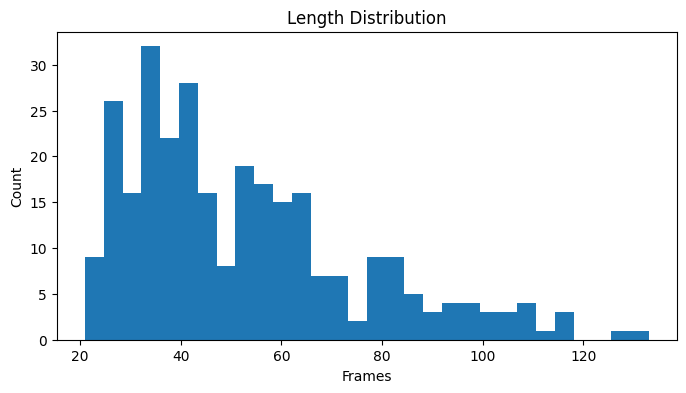

In [6]:
# --------------------------------------------------
# Histogram
# --------------------------------------------------

plt.figure(
    figsize=(8,4)
)

plt.hist(

    lengths,

    bins=30
)

plt.title(
    "Length Distribution"
)

plt.xlabel(
    "Frames"
)

plt.ylabel(
    "Count"
)

plt.show()

In [7]:
# --------------------------------------------------
# Bucket Statistics
# --------------------------------------------------

buckets = [

    (0,40),

    (40,60),

    (60,80),

    (80,100),

    (100,999)
]

bucket_lengths = {}

for low,high in buckets:

    vals = lengths[

        (lengths>=low)
        &
        (lengths<high)
    ]

    bucket_lengths[
        f"{low}-{high}"
    ] = vals

for name,vals in bucket_lengths.items():

    print()

    print(name)

    print(
        "samples:",
        len(vals)
    )

    if len(vals):

        print(
            "min:",
            vals.min()
        )

        print(
            "mean:",
            vals.mean()
        )

        print(
            "max:",
            vals.max()
        )


0-40
samples: 105
min: 21
mean: 31.304761904761904
max: 39

40-60
samples: 98
min: 41
mean: 49.30612244897959
max: 59

60-80
samples: 46
min: 61
mean: 68.8913043478261
max: 79

80-100
samples: 25
min: 81
mean: 87.84
max: 99

100-999
samples: 16
min: 101
mean: 110.875
max: 133


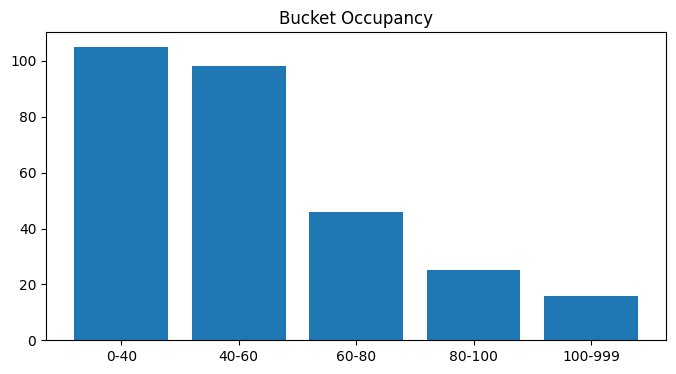

In [8]:
# --------------------------------------------------
# Bucket Occupancy
# --------------------------------------------------

names = []
counts = []

for k,v in bucket_lengths.items():

    names.append(k)

    counts.append(len(v))

plt.figure(
    figsize=(8,4)
)

plt.bar(
    names,
    counts
)

plt.title(
    "Bucket Occupancy"
)

plt.show()

In [9]:
# --------------------------------------------------
# Global Waste
# --------------------------------------------------

global_max = lengths.max()

global_waste = (

    global_max
    -
    lengths
).sum()

print(
    "Global Waste:",
    global_waste
)

Global Waste: 23312


In [10]:
# --------------------------------------------------
# Bucket Waste
# --------------------------------------------------

bucket_waste = 0

for vals in bucket_lengths.values():

    if len(vals)==0:
        continue

    bucket_max = vals.max()

    bucket_waste += (

        bucket_max
        -
        vals
    ).sum()

print(
    "Bucket Waste:",
    bucket_waste
)

print()

print(
    "Reduction (%):",
    100
    *
    (
        1
        -
        bucket_waste
        /
        global_waste
    )
)

Bucket Waste: 2856

Reduction (%): 87.74879890185312


In [11]:
# --------------------------------------------------
# Build Bucketed Loader
# --------------------------------------------------

loader = build_dataloader(

    PROJECT_ROOT,

    split="train"
)

batch = next(
    iter(loader)
)

batch.keys()

c:\Users\Dell\.conda\envs\betavae\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


dict_keys(['logmel', 'mr_mag_256', 'mr_mag_512', 'mr_mag_1024', 'magnitude', 'if', 'modgd', 'phase_sin', 'phase_cos', 'lengths', 'speaker', 'condition', 'split'])

In [12]:
# --------------------------------------------------
# Batch Shapes
# --------------------------------------------------

feature_names = [

    "logmel",

    "mr_mag_256",
    "mr_mag_512",
    "mr_mag_1024",

    "magnitude",

    "if",

    "modgd",

    "phase_sin",
    "phase_cos"
]

for name in feature_names:

    print(
        name,
        batch[name].shape
    )

logmel torch.Size([16, 80, 39])
mr_mag_256 torch.Size([16, 129, 77])
mr_mag_512 torch.Size([16, 257, 39])
mr_mag_1024 torch.Size([16, 513, 20])
magnitude torch.Size([16, 513, 39])
if torch.Size([16, 513, 39])
modgd torch.Size([16, 513, 39])
phase_sin torch.Size([16, 513, 39])
phase_cos torch.Size([16, 513, 39])


In [13]:
# --------------------------------------------------
# Length Spread Inside Batch
# --------------------------------------------------

print(

    batch["lengths"]
)

print()

print(
    "min",
    batch["lengths"].min()
)

print(
    "max",
    batch["lengths"].max()
)

print(
    "spread",
    batch["lengths"].max()
    -
    batch["lengths"].min()
)

tensor([33, 23, 33, 39, 37, 33, 31, 33, 27, 27, 33, 35, 31, 27, 25, 39])

min tensor(23)
max tensor(39)
spread tensor(16)


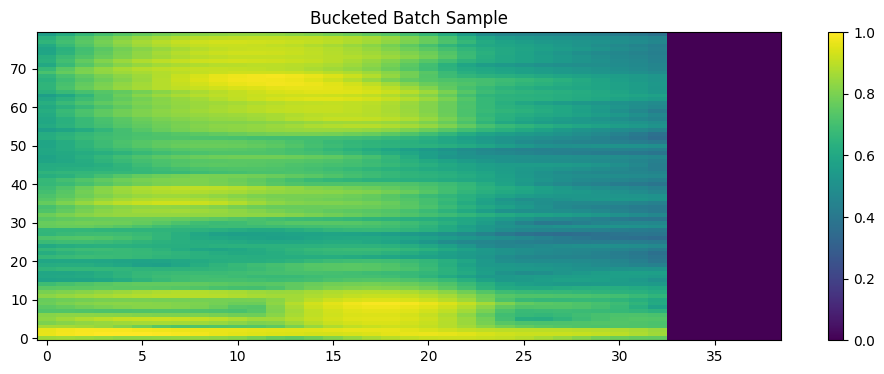

In [14]:
# --------------------------------------------------
# Batch Visualization
# --------------------------------------------------

idx = 0

plt.figure(
    figsize=(12,4)
)

plt.imshow(

    batch["logmel"][idx],

    aspect="auto",

    origin="lower"
)

plt.title(
    "Bucketed Batch Sample"
)

plt.colorbar()

plt.show()

In [15]:
# --------------------------------------------------
# Padding Ratio In This Batch
# --------------------------------------------------

max_len = int(

    batch["lengths"]
    .max()
)

waste = (

    max_len
    -
    batch["lengths"]
).sum()

capacity = (

    max_len
    *
    len(batch["lengths"])
)

print(
    "Padding Ratio:",
    waste.item()
    /
    capacity
)

Padding Ratio: 0.1891025641025641


In [16]:
# --------------------------------------------------
# Compare 10 Random Batches
# --------------------------------------------------

ratios = []

for batch in loader:

    max_len = int(

        batch["lengths"]
        .max()
    )

    waste = (

        max_len
        -
        batch["lengths"]
    ).sum()

    capacity = (

        max_len
        *
        len(batch["lengths"])
    )

    ratios.append(

        waste.item()
        /
        capacity
    )

    if len(ratios) == 10:
        break

print(
    "Mean Padding Ratio:",
    np.mean(ratios)
)

print(
    "Max Padding Ratio:",
    np.max(ratios)
)

Mean Padding Ratio: 0.16905211883467905
Max Padding Ratio: 0.21474358974358973


In [17]:
from src.models.factorized.feature_group_manager import (
    FeatureGroupManager
)

manager = FeatureGroupManager()

groups = manager.build_groups(
    batch
)

groups.keys()

dict_keys(['content', 'speaker', 'environment', 'excitation', 'fidelity'])

In [18]:
for group_name in groups:

    print()

    print(group_name)

    for feature_name,tensor in groups[group_name].items():

        print(
            feature_name,
            tensor.shape
        )


content
logmel torch.Size([16, 80, 59])
mr_mag_256 torch.Size([16, 129, 117])
if torch.Size([16, 513, 59])

speaker
mr_mag_512 torch.Size([16, 257, 59])
mr_mag_256 torch.Size([16, 129, 117])
logmel torch.Size([16, 80, 59])

environment
magnitude torch.Size([16, 513, 59])
mr_mag_1024 torch.Size([16, 513, 30])
if torch.Size([16, 513, 59])

excitation
modgd torch.Size([16, 513, 59])

fidelity
phase_sin torch.Size([16, 513, 59])
phase_cos torch.Size([16, 513, 59])
mr_mag_512 torch.Size([16, 257, 59])
mr_mag_1024 torch.Size([16, 513, 30])
magnitude torch.Size([16, 513, 59])
modgd torch.Size([16, 513, 59])
